In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from dataclasses import dataclass
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.nn import functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import random
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm, trange


/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/mwhealing/m

In [3]:
seed = 88
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [4]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
sd_hf = model_hf.state_dict()

for k,v in sd_hf.items():
    print(k,v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [5]:
with open('tokenizers/wiki_token.pkl', 'rb') as f:
    wiki_data = pickle.load(f)

def loadData(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data

wiki_data = loadData('tokenizers/wiki_token.pkl')
switchboard_data = loadData('tokenizers/switchboard_token.pkl')   
sub_titles_data = loadData('tokenizers/open_subtitles_token.pkl')    


combined_data = wiki_data + switchboard_data + sub_titles_data
random.shuffle(combined_data)
trainData = loadData('tokenizers/10M_data_token.pkl')
print(trainData[0])
print(len(trainData))

[320, 1654, 484, 389, 13, 29294, 826, 13, 545, 1654, 326, 2081, 13, 663, 257, 1256, 1180, 621, 1762, 287, 257, 3988, 38725, 13]
679066


In [6]:
# ==== Configuration ==== #
@dataclass
class ModelConfig:
    def __init__(self):
        self.block_size = 32 # context size (min num of tokens in sequence, how long model can see at once)
        self.vocab_size = 50256
        self.max_iters = 100
        self.n_head = 4
        self.n_embd = 64
        self.n_layers = 6
        self.dropout = 0.1
        self.bias: bool = True
        self.device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
                                          # switch out when transferring to github or stanage for cuda use

@dataclass
class TrainConfig:
    epochs: int = 50
    batch_size: int = 32
    max_len: int = 64
    pad: int = 0
    grad_accum_steps: int = 1
    max_lr: float = 3e-4
    min_lr: float = 1e-5
    warmup_iters: int = 100
    n_steps: int = 0
    lr_decay_iters: int = 1000
    save_every: int = 1
    save_every_steps:int = 2000
    # add optimiser hp





# Proxy Model 

In [7]:
@dataclass
class ProxyConfig:
    epochs:int = 2
    vocab_size:int = ModelConfig().vocab_size    # keep same vocab
    block_size:int = ModelConfig().block_size    # same context length
    batch_size:int = 32
    n_embd:int = 128                        # e.g. 1/4 or 1/8 of main
    n_head :int = 4                          # just enough heads
    n_layers:int = 2                          # really small depth
    dropout:float = 0.1
    bias: bool = False
    min_lr: float = 1e-4
    max_lr: float = 3e-4
    device  = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    # Proxy steps
    T_steps:int = 1_00
    t0:int = 5_0
    step:int = 0


In [8]:
class ProxyTrain(torch.nn.Module):
    def __init__(self, holdout_loader: DataLoader, score_loader: DataLoader, configs, model_cls):
        super().__init__()
        # Loader for training proxy
        self.holdout_loader = holdout_loader
        # Loader for computing learnability on unseen data
        self.score_loader = score_loader
        self.configs = configs
        self.device = configs.device

        # Build and move proxy model
        self.train_model = model_cls(configs).to(self.device)
        self.optim = torch.optim.AdamW(self.train_model.parameters(), lr=configs.max_lr)

        # Loss for training uses default (mean)
        self.Loss        = torch.nn.CrossEntropyLoss()
        # Model class for fresh instances
        self.model_cls   = model_cls

    def train(self):
        hold_iter = iter(self.holdout_loader)
        for step in trange(1, self.configs.T_steps + 1, desc="Proxy training"):
            try:
                x, y = next(hold_iter)
            except StopIteration:
                hold_iter = iter(self.holdout_loader)
                x, y = next(hold_iter)

            self.train_model.train()
            x, y = x.to(self.device), y.to(self.device)
            logits = self.train_model(x)  # [B, L, V]
            B, L, V = logits.shape

            loss = self.Loss(logits.view(B * L, V), y.view(-1))
            self.optim.zero_grad()
            loss.backward()
            self.optim.step()

            if step % 1000 == 0:
                print(f"Proxy step {step}/{self.configs.T_steps}, loss={loss.item():.4f}")

            if step == self.configs.t0:
                torch.save(self.train_model.state_dict(), "proxy_early.pt")
                print(f"Saved proxy early checkpoint at step {step}")

        # final checkpoint
        torch.save(self.train_model.state_dict(), "proxy_late.pt")
        print(f"Saved proxy final checkpoint at step {self.configs.T_steps}")


    def reductionLoss(self, model, inputs, targets):
        logits = model(inputs)         # [B, L, V]
        B, L, V = logits.shape
        loss_fn = torch.nn.CrossEntropyLoss(reduction="none")
        token_loss = loss_fn(logits.view(B * L, V), targets.view(-1))  # [B*L]
        seq_loss = token_loss.view(B, L).mean(dim=1)                   # [B]
        return seq_loss

    def LearnabilityScore(self):
        # Load early proxy
        early = self.model_cls(self.configs).to(self.device)
        early.load_state_dict(torch.load("proxy_early.pt", weights_only=True))
        early.eval()
        # Load late proxy
        late = self.model_cls(self.configs).to(self.device)
        late.load_state_dict(torch.load("proxy_late.pt", weights_only=True))
        late.eval()

        all_deltas = []
        with torch.no_grad():
            for x, y in tqdm(self.score_loader):
                x, y = x.to(self.device), y.to(self.device)
                loss_early = self.reductionLoss(early, x, y)
                loss_late  = self.reductionLoss(late,  x, y)
                delta = loss_early - loss_late
                all_deltas.append(delta)

        # return flat tensor of learnability scores
        return torch.cat(all_deltas, dim=0)

In [ ]:
class Scheduler:
    def __init__(self, train_data, scores, configs, schedule_type:str, init_beta:float, shuffle:bool ):
        super().__init__()

        self.train_data = train_data
        self.scores = scores
        self.configs = configs

        self.schedule_type = schedule_type
        self.init_beta = init_beta
        self.shuffle = shuffle

        self.sorted_idcs = self.scoreSort()
        self.sorted_score = self.scoreSort()

        self.gamma = 0.1

    def scoreSort(self):
        score = self.scores.cpu().numpy() # make sure still a tensor when passed

        pairs = list(enumerate(score))
        sorted_pairs = sorted(pairs, key=lambda pair: pair[1])
        sorted_idcs = [idc for idc, _ in sorted_pairs]

        return sorted_idcs
    
    def lyapunovReguliser(self, epoch, lambda_n):
        if len(lambda_n)<2:
            return 1.
        
        delta_lambda = lambda_n[-1] - lambda_n[-2]
        alpha = 1.

        if delta_lambda >= 0: # unstable condition => reduce speed
            alpha *= (1 - self.gamma*lambda_n[-1]/(1 + epoch))

        else: # stable condition => increase speed
            alpha *= (1 + self.gamma*lambda_n[-1]/(1 + epoch))

        return alpha

    def betaSchedule(self,epoch, alpha): # alpha is inital sampling size. 
        
        # adaptive scaling. adapt during training based on validation performance?
        # if feedback (val) stronger than scaling type, will schedule type wash out?
        E_n = epoch / self.configs.epochs # current epoch ratio
        eps = 1e-8
        if self.schedule_type == 'linear': # schedules the sampling linearly (default)
            beta_t = min(1., self.init_beta + E_n)
        if self.schedule_type == 'sigmoid':
            beta_t = (1 + math.exp(-alpha * E_n))**-1 
        if self.schedule_type == 'tanh':
            beta_t = 0.5*math.tanh(alpha * E_n) + 0.5
        if self.schedule_type == 'log':
            beta_t = min(1., math.log(alpha * E_n + eps))
        if self.schedule_type == 'exp':
            beta_t = min(1., math.exp(alpha * E_n) - 1)

        # sampling %
        cutoff = int(beta_t * len(self.sorted_score))
        sample_idcs = self.sorted_idcs[:cutoff] # sample from sorted indicies 

        if self.shuffle:
            random.shuffle(sample_idcs) # shuffle idcs in sample
        return sample_idcs

    def seqentialBatch(self, epoch, alpha):
        sampled_idcs = self.betaSchedule(epoch, alpha)
        subset = torch.utils.data.Subset(self.train_data, sampled_idcs)
        
        train_loader = DataLoader(
            subset, 
            batch_size=self.configs.batch_size,
            )
        return train_loader

# GPT2 Decoder #

Components:

1. Token Embeddings - Map token ids to dense vecs

2. Positional Encoding - add positional info to embeddings

3. Transformer Blocks (n) - self-attention + feed foward layers

4. Casual masking - prevents peeking into future

5. Final Linear Layer - projects to vocab size (logits)

In [10]:
# ==== GPT2 Decoder ==== #

### UPDATE FOR TORCH USE ###

class GPT2Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.config = config

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias) # create W attn embds
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        # layer norm
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)

        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias), # expand dims (4 * from Attention all u need paper)
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd), # project back 
            nn.Dropout(config.dropout)
        )
        
        self.attn_dropout = nn.Dropout(config.dropout)

    def Mask(self, t):
        mask = torch.tril(torch.ones((t,t), device=self.config.device)).unsqueeze(0).unsqueeze(0)
        return mask

    def SelfAttention(self,x, mask=None):
        b,t,c = x.shape
        q, k, v = self.c_attn(x).split(self.config.n_embd, dim=2)
        
        q =q.reshape(b, t, self.config.n_head, c//self.config.n_head).permute(0,2,1,3)
        k = k.reshape(b, t, self.config.n_head, c//self.config.n_head).permute(0,2,1,3)
        v = v.reshape(b, t, self.config.n_head, c//self.config.n_head).permute(0,2,1,3)

        score = (q @ k.transpose(-2,-1)) / math.sqrt(k.shape[-1])

        if mask is None:
            mask = self.Mask(t)
        score = score.masked_fill(mask==0, float("-inf"))

        a = nn.functional.softmax(score, dim=-1)
        a = self.attn_dropout(a)
        head = a @ v
        out = head.permute(0,2,1,3).reshape(b,t,c) # back to input dims
        out = self.c_proj(out)
        #print("Type of self.SelfAttention(x):", type(out))
        return out
    
    def forward(self, x, mask=None):
        # self attention ad layer norm
        x = x + self.SelfAttention(self.ln1(x), mask)
        x = x + self.mlp(self.ln2(x)) # resudual connections
       
        return x
    

class GPT2Model(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.token_embd = nn.Embedding(config.vocab_size, config.n_embd)
        self.posn_embd = nn.Embedding(config.block_size, config.n_embd)

        self.proj = nn.Linear(config.n_embd, config.vocab_size)

        self.blocks = nn.Sequential(*[GPT2Block(config) for _ in range(config.n_layers)])
        self.fln = nn.LayerNorm(config.n_embd)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.ones_(module.weight)
            torch.nn.init.zeros_(module.bias)

    def forward(self, x):
        b, t = x.size()
        tokn_embd = self.token_embd(x)
        posn_idcs = torch.arange(t, device=x.device).unsqueeze(0).expand(b,t)
        posn_embd = self.posn_embd(posn_idcs)

        x = tokn_embd + posn_embd

        x = self.blocks(x)
        x = self.fln(x) # final linear layer
        return self.proj(x) # project back to (enbedding size, vocab size)



class GPTTrainer:
    def lr_schedule(self, optim, train_config):
        def lr_lambda(current_step):
            if current_step < train_config.warmup_iters:
                return float(current_step) / float(max(1, train_config.warmup_iters))
            return max(0.0, float(train_config.total_steps - current_step) / float(max(1, train_config.total_steps - train_config.warmup_iters)))
        return LambdaLR(optim, lr_lambda)

    def __init__(self, x, y, train_loader, val_loader, train_config, model_config, scheduler, check_points_dir=None):
        self.x, self.y = x, y
        self.train_config = train_config
        self.check_points_dir = check_points_dir

        self.train_loader = train_loader
        self.val_loader = val_loader
        self.scheduler = scheduler

        self.device = model_config.device

        self.train_config.total_steps = self.train_config.epochs * len(self.train_loader)

        self.model = GPT2Model(model_config).to(self.device)
        self.optim = torch.optim.AdamW(self.model.parameters(), lr=train_config.max_lr)
        self.schedule = self.lr_schedule(self.optim, self.train_config)
        self.criterion = nn.CrossEntropyLoss()

        self.step_count = 0

        # lyponav regularisation
        self.L0 = None # get initial val loss
        self.prev_val_loss = None # get prev val loss
        self.lambdas = [] # track lambda of leraning over time


    def step(self, inputs, targets):
        self.model.train()
        inputs = inputs.to(self.device)
        targets = targets.to(self.device)

        logits = self.model(inputs)
        b, t, v = logits.shape
        logits = logits.view(b * t, v)
        targets = targets.view(b * t)

        loss = self.criterion(logits, targets) / self.train_config.grad_accum_steps
        loss.backward()

        if (self.step_count + 1) % self.train_config.grad_accum_steps == 0:
            self.optim.step()
            self.schedule.step()
            self.optim.zero_grad()

        self.step_count += 1

        if (self.check_points_dir and self.step_count % self.train_config.save_every_steps == 0):
            checkpoint = {
                "step": self.step_count,
                "model": self.model.state_dict(),
                "optim": self.optim.state_dict(),
                "schedule": self.schedule.state_dict()
            }
            torch.save(checkpoint, f"{self.check_points_dir}/checkpoint_step_{self.step_count}.pt")
            print(f" ------> Saved Checkpoint at {self.step_count}")

        if self.step_count % 1000 ==0:
            print(f"Step {self.step_count:04d} | Loss: {loss.item():.4f}")
        return loss.item()

    def validate(self, val_loader):
        self.model.eval()

        total_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(self.device)
                y = y.to(self.device)

                logits = self.model(x)
                b, t, v = logits.shape
                logits = logits.view(b * t, v)
                y = y.view(b * t)

                loss = self.criterion(logits, y)
                total_loss += loss.item()
        return total_loss / len(val_loader)

    def train(self):

        alpha = 1.
        train_loss_arr = []
        val_loss_arr = []
        alpha_arr = []
        lambdas_arr = []

        for epoch in range(self.train_config.epochs):
            total_loss = 0.
            n_batches = 0
            if self.lambdas:
                alpha *= self.scheduler.lyapunovReguliser(epoch, self.lambdas)
                alpha_arr.append(alpha)
                lambdas_arr.append(self.lambdas[-1])

            train_loader = self.scheduler.seqentialBatch(epoch, alpha)

            if self.step_count > 0:
                current_lr = self.optim.param_groups[0]['lr']
                print(f"Epoch {epoch + 1} | LR: {current_lr:.6f}")
            else:
                print(f"Epoch {epoch + 1} | Starting warmup...")

            for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}, alpha {alpha}"):
                loss_val = self.step(x, y)
                total_loss += loss_val
                n_batches += 1

            avg_loss = total_loss / n_batches
            train_loss_arr.append(total_loss)
            print(f"Epoch {epoch + 1} | Avg Loss: {avg_loss:.4f}")

    
            val_loss = self.validate(self.val_loader)
            val_loss_arr.append(val_loss)

            # regularise sample scaling 
            if self.L0 is None:
                self.L0 = val_loss # get initial validation loss
            if self.prev_val_loss is not None:
                delta_L = val_loss - self.prev_val_loss
                if delta_L != 0:
                    lambda_n = (1/(1+epoch)) * math.log(abs(delta_L)/self.L0)  # measure divergence
                    self.lambdas.append(lambda_n)
                    print(lambda_n)

            self.prev_val_loss = val_loss # update prev

            print(f"Epoch {epoch + 1} | Validation Loss: {val_loss:.4f}")
            

            if self.check_points_dir and (epoch + 1) % self.train_config.save_every == 0:
                torch.save(self.model.state_dict(), f"{self.check_points_dir}/model_epoch_{epoch + 1}.pt")
        return train_loss_arr, val_loss_arr, alpha_arr, lambdas_arr



# Helper function for filtering logits using top-k and/or nucleus (top-p) sampling
def top_k_top_p_filtering(logits, top_k=0, top_p=0.0, filter_value=-float('Inf')):

    # Top-K filtering: keep only k highest tokens
    if top_k > 0:
        values, indices = torch.topk(logits, top_k)
        threshold = values[-1]
        logits[logits < threshold] = filter_value

    # Top-p (nucleus) filtering
    if top_p > 0.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
        # Remove tokens with cumulative probability above the threshold
        sorted_indices_to_remove = cumulative_probs > top_p
        # Shift the indices to retain the first token above the threshold
        sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
        sorted_indices_to_remove[..., 0] = 0

        indices_to_remove = sorted_indices[sorted_indices_to_remove]
        logits[indices_to_remove] = filter_value
    return logits


class GenerateGPT:
    def __init__(self, model, tokenizer, prompt, max_len=50):

        self.model = model
        self.tokenizer = tokenizer
        self.prompt = prompt
        self.max_len = max_len

    def generate(self, temperature=1.0, top_k=0, top_p=0.0):
        # Set model to evaluation mode
        self.model.eval()

        # Encode the prompt into token IDs (assumes tokenizer provides a numerical encoding)
        # Make sure the prompt is encoded as a list of token IDs.
        input_ids = self.tokenizer.encode(self.prompt)
        input_tensor = torch.tensor([input_ids], device=next(self.model.parameters()).device)

        # Autoregressive generation loop
        with torch.no_grad():
            for _ in range(self.max_len):
                logits = self.model(input_tensor)
                next_token_logits = logits[0, -1, :]

                # Scale logits by temperature
                next_token_logits = next_token_logits / temperature

                # Apply top-k/top-p filtering if required
                filtered_logits = top_k_top_p_filtering(next_token_logits.clone(), top_k=top_k, top_p=top_p)
                probabilities = F.softmax(filtered_logits, dim=-1)

                # Sample the next token
                next_token = torch.multinomial(probabilities, num_samples=1).item()

                # Append sampled token to input_ids tensor
                input_tensor = torch.cat([input_tensor, torch.tensor([[next_token]], device=input_tensor.device)], dim=1)

                if next_token == self.tokenizer.eos_token_id: #end of sequence token
                    break

        # Decode the tokens back to text
        generated_text = self.tokenizer.decode(input_tensor[0].tolist())
        return generated_text

 


# Text Generation # 

Predicts next token from the given context. 

1. Input [cat sat on mat] -> token representation 

2. Feed tokens to the trained model. It will output tensor with shape [batch_size, seq_len, vocab_size], which will have the probability distribution over the vocab at each position. Only care about the last position to predict next token.

3. Pick the token. From the final distribution: Argmax for highest prob, or sample from the distribution (more creative) or use top-k/top-p (nucleus) sampling to balance diversity and equity. Then simply append token to sequence.

4. Repeat, feed the model the updated sequence back in and repeat 2 and 3 until a max length is reached or model generates and end of sequence token.

### Casual Masking ###
In training and generation, model cant peak into the future.

Tests:
- Different prompt lengths
- Adjust temperature (controls randomness in sampling)
- Add stop conditions (e.g if it generates a period or newline)
- see how model behaves w/ different types of prompt

In [11]:
with open('tokenizers/wiki_token.pkl', 'rb') as f:
    wiki_data = pickle.load(f)

def loadData(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data

wiki_data = loadData('tokenizers/wiki_token.pkl')
switchboard_data = loadData('tokenizers/switchboard_token.pkl')   
sub_titles_data = loadData('tokenizers/open_subtitles_token.pkl')    

combined_data = wiki_data + switchboard_data + sub_titles_data
random.shuffle(combined_data)
trainData_10 = loadData('tokenizers/10M_data_token.pkl') # on the 10M data
trainData_100 = loadData('tokenizers/100M_data_token.pkl') # on the 100M data
print(trainData_10[0])
print(len(trainData_10))

[320, 1654, 484, 389, 13, 29294, 826, 13, 545, 1654, 326, 2081, 13, 663, 257, 1256, 1180, 621, 1762, 287, 257, 3988, 38725, 13]
679066


In [12]:
from collections import Counter
tokens = [token for seq in trainData_10 for token in seq]
counts = Counter(tokens)
print(counts.most_common(10))

[(13, 873291), (11, 438663), (262, 392638), (284, 195145), (30, 194215), (257, 192449), (345, 190609), (290, 186148), (286, 161859), (287, 135855)]


In [13]:
flat_tokens = [token for sublist in trainData_10 for token in sublist]
flat_tokens = flat_tokens[:100_000] # just for testing

In [14]:

block_size = ModelConfig().block_size
flat_tokens_np = np.array(flat_tokens, dtype=np.int32)

n_samples = len(flat_tokens_np) - block_size

X = np.lib.stride_tricks.sliding_window_view(flat_tokens_np, block_size)[:-1]
Y = np.lib.stride_tricks.sliding_window_view(flat_tokens_np[1:], block_size)

# get final test set
X_rest, X_test, y_rest, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=88
)

# get main val set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_rest, y_rest, test_size=0.25, random_state=88
)

# *split X_train_full* into actual train set and proxy-holdout
X_train_main, X_hold, y_train_main, y_hold = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10,    # 10% of the 60% = 6% of total
    random_state=42
)

X_train_tensor = torch.tensor(X_train_main, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_main, dtype=torch.long)

X_val_tensor   = torch.tensor(X_val, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)

X_hold_tensor = torch.tensor(X_hold, dtype=torch.long) # proxy model
y_hold_tensor = torch.tensor(y_hold, dtype=torch.long)




In [15]:
model_config = ModelConfig()
train_config = TrainConfig()
proxy_configs = ProxyConfig()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
hold_dataset = TensorDataset(X_hold_tensor, y_hold_tensor) # for proxy model
score_dataset = TensorDataset(X_train_tensor, y_train_tensor) # for irreducible 

train_loader = DataLoader(train_dataset, batch_size=train_config.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=train_config.batch_size)
holdout_loader = DataLoader(hold_dataset, batch_size=proxy_configs.batch_size) # proxy
score_loader = DataLoader(train_dataset, batch_size=proxy_configs.batch_size, shuffle=False) #irreducilbe 


In [16]:


proxy_trainer = ProxyTrain(holdout_loader, score_loader, proxy_configs, GPT2Model)
proxy_trainer.train()

# get scores
scores = proxy_trainer.LearnabilityScore()


Proxy training:  53%|█████▎    | 53/100 [00:04<00:03, 12.52it/s]

Saved proxy early checkpoint at step 50


Proxy training: 100%|██████████| 100/100 [00:08<00:00, 12.36it/s]


Saved proxy final checkpoint at step 100


100%|██████████| 1687/1687 [01:26<00:00, 19.52it/s]


In [17]:
scheduler = Scheduler(
    train_dataset, 
    scores, 
    configs=proxy_configs, 
    schedule_type='linear', 
    init_beta=0.3, 
    shuffle=True
    )

sorted_idcs = scheduler.scoreSort()
print(len(sorted_idcs))

sampled_idc = scheduler.betaSchedule(epoch=1, alpha=1.1)
print(sampled_idc)

loader = scheduler.seqentialBatch(epoch=10, alpha=1.1)
for i, (x, y) in enumerate(loader):
    print("global index:", sorted_idcs[i], " example:", x[:5], "...") 
    if i == 5: break

53982
[8979, 41650, 47120, 49087, 6686, 25507, 13329, 17781, 33810, 44131, 40028, 35492, 4220, 52883, 8821, 32774, 51089, 47827, 50255, 34249, 1963, 9787, 35476, 5317, 37352, 12572, 19955, 53922, 8995, 51475, 9013, 45658, 6004, 9028, 41405, 13737, 31540, 11473, 43344, 634, 28739, 30233, 28247, 29831, 4607, 10807, 9, 43029, 22213, 31306, 2190, 53792, 39956, 32512, 1813, 36262, 51818, 6164, 20885, 49869, 24126, 32546, 6138, 9625, 23984, 52420, 28929, 15232, 48995, 28234, 28012, 51535, 10371, 37339, 38315, 8533, 45775, 38786, 15602, 38741, 27032, 31050, 49587, 26936, 32298, 2032, 1106, 32475, 7674, 40545, 26923, 48689, 49994, 37280, 1616, 29405, 19952, 21828, 26626, 706, 51287, 26474, 17382, 23473, 45347, 19796, 49250, 24296, 11415, 24116, 41119, 41991, 4774, 26753, 50335, 49763, 10196, 34655, 34080, 29510, 36903, 24449, 17885, 5931, 3417, 37323, 26311, 16897, 253, 9377, 8258, 20598, 2154, 16130, 39979, 20163, 34687, 48095, 52041, 15046, 35667, 35083, 51282, 9183, 36743, 8569, 42840, 3991

In [18]:


trainGPT = GPTTrainer(
    X_train_tensor, 
    y_train_tensor, 
    train_loader, 
    val_loader,    
    train_config,  
    model_config, 
    scheduler  
)


train_loss, val_loss, alphas, lambdas = trainGPT.train()



Epoch 1 | Starting warmup...


Epoch 1, alpha 1.0: 100%|██████████| 507/507 [00:34<00:00, 14.75it/s]


Epoch 1 | Avg Loss: 7.2555
Epoch 1 | Validation Loss: 5.4503
Epoch 2 | LR: 0.000299


Epoch 2, alpha 1.0:  37%|███▋      | 496/1350 [00:33<00:57, 14.96it/s]

Step 1000 | Loss: 4.7390


...

Epoch 49 | Avg Loss: 0.8381
-0.1456015292975626
Epoch 49 | Validation Loss: 0.6333
Epoch 50 | LR: 0.000011


Epoch 50, alpha 1.0798646580707825:  51%|█████     | 856/1687 [00:55<00:54, 15.39it/s]

Step 82000 | Loss: 0.9265


Epoch 50, alpha 1.0798646580707825: 100%|██████████| 1687/1687 [01:49<00:00, 15.35it/s]


Epoch 50 | Avg Loss: 0.8315
-0.16083601914364248
Epoch 50 | Validation Loss: 0.6316


In [19]:
print(train_loss)
print(val_loss)
print(alphas)
print(lambdas)

[3678.5464448928833, 6296.675957202911, 6185.382164001465, 5230.667824983597, 4559.800135374069, 4063.8557032346725, 3681.7553033828735, 3383.6118457317352, 3139.3106532096863, 2940.290319800377, 2772.4568308591843, 2634.1643664836884, 2517.935723900795, 2418.241898536682, 2330.838392496109, 2255.099744915962, 2186.232473015785, 2128.2070628404617, 2074.123027920723, 2025.7965522408485, 1979.062824010849, 1940.133815586567, 1901.3718356490135, 1866.627382338047, 1835.137915790081, 1804.1149874925613, 1777.4632108211517, 1748.757492184639, 1724.6482033133507, 1699.4712793827057, 1679.123048722744, 1657.9696367383003, 1636.8707351088524, 1617.5573199391365, 1599.4541813731194, 1583.7078439593315, 1565.3178636431694, 1548.8930131793022, 1534.4764404892921, 1519.383875131607, 1505.601127564907, 1492.1337299346924, 1478.8525290489197, 1465.9967685341835, 1454.4542471170425, 1443.3607960939407, 1432.9533473849297, 1422.4305425286293, 1413.8231263756752, 1402.6853649616241]
[5.450294722747802

[]

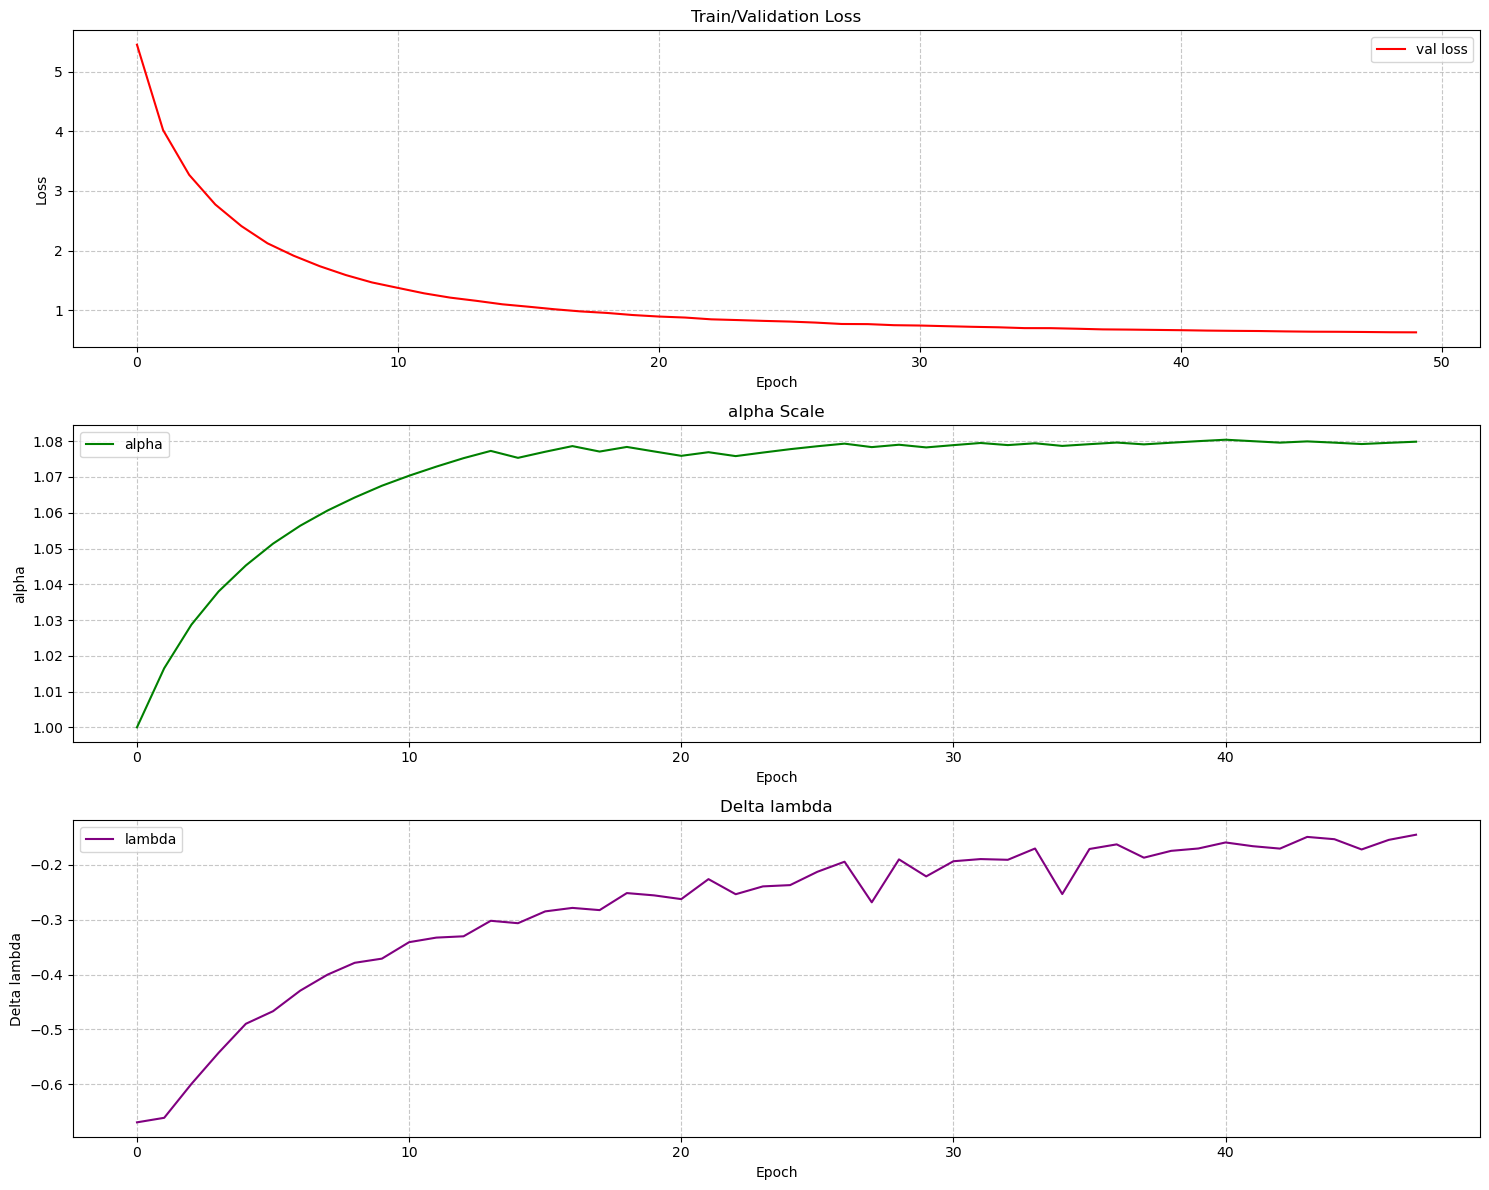

In [26]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15,12))

epochs = np.arange(len(train_loss))  
epochs_alpha = np.arange(len(alphas)) 
epochs_lambda = np.arange(len(lambdas))

#ax[0].plot(train_loss, label='train loss', color='blue')
ax[0].plot(epochs, val_loss, label='val loss', color='red')
ax[0].set_title("Train/Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

ax[1].plot(epochs_alpha, alphas, label='alpha', color='green')
ax[1].set_title(f"alpha Scale")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel(f"alpha")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

ax[2].plot(epochs_lambda, lambdas, label='lambda', color='purple')
ax[2].set_title(f"Delta lambda")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel(f"Delta lambda")
ax[2].legend()
ax[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.plot()


In [27]:
tokeniser = GPT2Tokenizer.from_pretrained('gpt2')
tokeniser.pad_token = tokeniser.eos_token

generator = GenerateGPT(model=trainGPT.model, tokenizer=tokeniser, prompt="Once upon a time, there was a dragon who loved pancakes.", max_len=100)

text = "Once upon a time, there was a dragon who loved pancakes."
tokens = tokeniser.encode(text)

output_text = generator.generate(temperature=1., top_k=50, top_p=.9)
print("Generate Text")
print(output_text)
ids = tokeniser.encode("Would you like to go outside with me")
print(tokeniser.convert_ids_to_tokens(ids))


Generate Text
Once upon a time, there was a dragon who loved pancakes. if i still was my turned building that, then. and then i put it in parenthesis. i take it recently. i take it so, i take it so i take it under the right after i take it recently. to keep it so i take it and let it under the right after i take it so, i take it so i take it under the phonethats found himbutand also set out of the in there and im used to do you strictly backpack?mostly. i
['Would', 'Ġyou', 'Ġlike', 'Ġto', 'Ġgo', 'Ġoutside', 'Ġwith', 'Ġme']


In [ ]:
# Save final model checkpoint
torch.save(trainGPT.model.state_dict(), "final_gpt_model.pt")


In [13]:
# Rebuild model with the same config
model = GPT2Model(model_config)  
model.load_state_dict(torch.load("final_gpt_model.pt"))
model.to(torch.device)  # don't forget to move to device!
model.eval()      # if using for inference


NameError: name 'model_config' is not defined

# Irreducible and Entropy #


### Proxy Model ###

Scaled down gpt2 decoder

In [21]:
proxy_trainer = ProxyTrain(holdout_loader, score_loader, proxy_configs, GPT2Model)
proxy_trainer.train()

Proxy training:  52%|█████▏    | 52/100 [00:06<00:05,  8.17it/s]

Saved proxy early checkpoint at step 50


Proxy training: 100%|██████████| 100/100 [00:12<00:00,  7.89it/s]


Saved proxy final checkpoint at step 100


In [24]:
scores = proxy_trainer.LearnabilityScore()

100%|██████████| 1687/1687 [01:46<00:00, 15.80it/s]


In [25]:
print(scores.size())
print(scores)

torch.Size([53964])
tensor([1.4918, 1.5760, 1.5739,  ..., 1.4164, 1.8055, 1.3325], device='mps:0')


In [ ]:
        # linear and sigmoid to start
        # embed in config params w/ beta_start, beta_end, schedule type and T_total (len of train data loader)

        # compute cutoff, beta(t) x 100% of data
        #cutoff = int(beta * N) , N = total training examples
        # then use sorted_idcs[:cutoff]

        # scheduler class gets t and t_total, cutoff method and sequential batch (maybe step or epoch arg to rebuild sampler on fly)

        # GPT trainer loop gets at start of each epoch or n steps compute the cutoff and get new sampler/loader from Scheduler
        # swap the training loader for updated loader. maybe comp beta in trainier since its already time based
        

        # ___ method ___ #
        # pre-comp sorted idcs in scheduler
        # At each epoch/ n steps: cutoff = int(beta * N), call scheduler for the cutoff to get a dataloader for gradually harder samples.
        # pass loader into gpt training step for the epoch (final epoch cutoff=N)

        #could mix in to make sure some hard examples are always present, min_hard = N - max(1,N*beta)

### Entropy Guided ###



# VAE BILSTM #

In [ ]:
# ==== VAE w/ BiLSTM ==== #

class VAEBiLSTM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.embd = nn.Embedding(config.vocab_size, config.embd_dim, config.pad_idx)
        #assert config.input_dim == config.embd_dim 

        # biLSTM encoder
        self.encoder = nn.LSTM(
            config.embd_dim, 
            config.hidden_dim, 
            config.n_layers, 
            batch_first=True, 
            bidirectional=True) # returns tensor (batch size, seq len, 2 * hidden size)
        
        self.h_to_mu = nn.Linear(2 * config.hidden_dim, config.latent_dim)
        self.h_to_logVar = nn.Linear(2 * config.hidden_dim, config.latent_dim)

        # Decoder (transformer)
        self.z_embd = nn.Linear(config.latent_dim, config.embd_dim)

        self.decode = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(d_model=config.embd_dim, 
                                       nhead=config.decoder_heads,
                                       dropout=config.dropout),
                                       num_layers=config.n_layers
                                       )
         # maybe if time try RoPE posn embeddings

        # positional embd for target
        self.posn_embd_target = nn.Embedding(config.block_size, config.embd_dim) #n_embd or embd_dim?

        self.posn_embd = nn.Embedding(config.block_size, config.embd_dim)
        self.token_embd = nn.Embedding(config.vocab_size, config.embd_dim)
        self.proj_out = nn.Linear(config.embd_dim, config.vocab_size)

    def Encode(self, x):
        x = self.embd(x) # [batch, seq len, embd dim]
        #print(x.shape)

        out, (hn, cn) = self.encoder(x)

        ht = torch.concat((hn[-2], hn[-1]), dim=1) # summary rep, last back and forward layers

        mu = self.h_to_mu(ht)
        logVar = self.h_to_logVar(ht)

        return mu, logVar
    
    def Reparameterise(self, mu, logVar):
        std = torch.exp(0.5 * logVar)
        eps = torch.randn_like(std)
        z = mu + eps*std
        return z # z shape [batch, hidden]
    
    def Decode(self, z, target_seq):
        proj_z = self.z_embd(z) # [batch (input shape), embd]

        # embed target seq
        target_embd = self.embd(target_seq) #[batch, seq, embd]
        target_embd = target_embd.transpose(0,1) #[seq, batch, embd] 

  
        b, t = target_seq.size()
       
        posn_idc = torch.arange(t, device=z.device).unsqueeze(0).expand(b,t)
        posn_embd = self.posn_embd_target(posn_idc)
        posn_embd = posn_embd.transpose(0,1)
   
        #print("posn",posn_embd.size())
        #print('target',target_embd.size())
        target = target_embd + posn_embd
        target = target.transpose(0,1) # transformer needs [seq, batch, embd]

        proj_z = proj_z.unsqueeze(1).expand(-1, t, -1) # [batch, t, embd_dim]
        #print('proj_z size', proj_z.size())
        memory =  proj_z # projected z for conditioning [t, batch, embd]
        #print('memory size', memory.size())
        #print('target size', target.size())
      
        out = self.decode(tgt=target, memory=memory) # [seq, batch, embd]

        # project to output shape [seq, batch, embd] -> [seq, batch, vocab len]
        out = self.proj_out(out)

        return out

    def forward(self, x, target_seq):
        mu, logvar = self.Encode(x)
        z = self.Reparameterise(mu, logvar)
        return z, self.Decode(z, target_seq), mu, logvar

    
        


In [ ]:
class TrainBiLSTMVAE(nn.Module):
    def __init__(self, x, y, train_config, model_config):
        super().__init__()
        self.x = x
        self.y = y

        self.train_config = train_config
        self.model_config = model_config

        self.device = model_config.device

        self.loader = DataLoader(
            self.x, self.y, 
            model_config.batch_size,
            train_config.max_len,
            train_config.pad_token
        ) 

        # int model
        self.model = VAEBiLSTM(model_config).to(self.device)
        self.optim = torch.optim.AdamW(self.model.parameters(), lr=train_config.max_lr)

        self.global_step = 0
        
    def LossFunc(self, recon_x, x, mu, logvar):
        total_steps = self.train_config.epochs * len(self.loader)

        beta = min(1.0, self.global_step / (total_steps * self.train_config.kl_speed))
        #beta = 0


        recon_x = recon_x.view(-1, self.model_config.vocab_size)
        x = x.view(-1)

        CE = F.cross_entropy(recon_x, x, ignore_index=self.model_config.pad_idx, reduction='mean')

        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        KLD = KLD / recon_x.size(0)  # normalize over batch
        print("KL:", KLD.item(), "CE:", CE.item())


        return CE + beta * KLD


    def TrainStep(self):
        self.model.train()
        self.device = torch.device("cpu") # need to change this for testing on stanage for cude
        self.model.to("cpu") #mps compatibility issues with lstm module on torch
        epoch_losses = []

        for epoch in range(self.train_config.epochs):
            running_loss = 0.0

            for batch_x, _ in self.loader:
                self.global_step += 1
                batch_x = batch_x.long().to(self.device)
                #print("First batch shape:", batch_x.shape)


                self.optim.zero_grad()

                z, recon_x, mu, logvar = self.model(batch_x, batch_x)  # input = target for teacher forcing
                loss = self.LossFunc(recon_x, batch_x, mu, logvar)

                loss.backward()
                self.optim.step()

                running_loss += loss.item()

            avg_loss = running_loss / len(self.loader)
            epoch_losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{self.train_config.epochs} | Loss: {avg_loss:.4f}")

        return epoch_losses 




In [ ]:
@dataclass
class VAEConfig:
    batch_size: int = 8
    hidden_dim: int = 1024
    embd_dim: int = 128
    latent_dim:int = 64
    input_dim: int = 64
    n_layers: int = 1
    pad_idx: int = 0
    vocab_size: int = 50255 # max token val
    decoder_heads: int = 8
    dropout: float = 0.1 # dropout for transformer decoder
    block_size: int = 100 # match seqence length
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
                        # switch out when transferring to github or stanage for cuda use


@dataclass
class VAETrainConfig:
    epochs: int = 30
    max_lr: float = 5e-4
    min_lr: float = 1e-5
    device:  torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    max_len: int = 100
    pad_token: int = 0
    kl_speed = 1
   # batch_size:int = 8

In [ ]:
print(len(X_train))

vae_trainer = TrainBiLSTMVAE(X_train, y_train, VAETrainConfig, VAEConfig)
losses = vae_trainer.TrainStep()

146328
KL: 0.0005120969726704061 CE: 11.01603889465332
Epoch 1/30 | Loss: 0.0006
KL: 0.0006616286700591445 CE: 10.896020889282227
Epoch 2/30 | Loss: 0.0006
KL: 0.0008665387285873294 CE: 10.686738967895508
Epoch 3/30 | Loss: 0.0006
KL: 0.0015674046007916331 CE: 10.54519271850586
Epoch 4/30 | Loss: 0.0006
KL: 0.0020198815036565065 CE: 10.409372329711914
Epoch 5/30 | Loss: 0.0006
KL: 0.00527367414906621 CE: 10.295669555664062
Epoch 6/30 | Loss: 0.0006
KL: 0.008542085997760296 CE: 10.18830394744873
Epoch 7/30 | Loss: 0.0006
KL: 0.01544257439672947 CE: 10.18809700012207
Epoch 8/30 | Loss: 0.0006
KL: 0.11881127208471298 CE: 10.14050579071045
Epoch 9/30 | Loss: 0.0006
KL: 0.035955000668764114 CE: 9.931495666503906
Epoch 10/30 | Loss: 0.0005
KL: 0.033493366092443466 CE: 9.690995216369629
Epoch 11/30 | Loss: 0.0005
KL: 0.03108862228691578 CE: 9.680652618408203
Epoch 12/30 | Loss: 0.0005
KL: 0.020024003461003304 CE: 9.57498550415039
Epoch 13/30 | Loss: 0.0005
KL: 0.01652737893164158 CE: 9.555003

In [ ]:
from sklearn.decomposition import PCA


Visualise latents. look for semantic similarity, helps to show if simpler inputs are mapped to more compact and confident region are formed because of irreducile and entropy. 

Detects posterior collapse (all z are crammed into small region)

Training progression tracked, can see how it evolves across epochs

Can plot entropy or difficulty vs position in latent space

Work out how to color code for semantic similarity, mark sequences by curriculum, possibly show evolution over epochs

# VAE first then curriculum or curriculum then VAE ? #

reduce timie to convergence

potentially reduce overfitting 

potentially outperform naivly trained models 